### Imports

In [1]:
import os
import random
import glob
import warnings
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchaudio

import librosa
import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

SEED = 23456543
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


### Config

In [2]:
DATA_ROOT = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup"
OUTPUT_DIR = "./outputs"

STEMS_DIR = os.path.join(DATA_ROOT, "genres_stems")
NOISE_DIR = os.path.join(DATA_ROOT, "ESC-50-master", "audio")
TEST_DIR = os.path.join(DATA_ROOT, "mashups")
TEST_CSV = os.path.join(DATA_ROOT, "test.csv")

# audio params
SR = 22050 # Sampling Rate
DURATION = 10.0 # 10s
TARGET_LEN = int(SR * DURATION) # 220500 samples
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
FMIN = 20
FMAX = 8000

GENRES = sorted(['blues', 'classical', 'country', 'disco', 'hiphop',
                 'jazz', 'metal', 'pop', 'reggae', 'rock'])


GENRES2IDX = {g : i for i, g in enumerate(GENRES)}
IDX2GENRES = {i : g for g, i in GENRES2IDX.items()}
STEMS = ["drums", "vocals", "bass", "other"]

SAMPLES_PER_GENRE = 1000 # 10k mashups per epoch
BATCH_SIZE = 32
EPOCHS = 35
LR = 1e-3
WEIGHT_DECAY = 1e-4 # l2-reg
LABEL_SMOOTHING = 0.1 # better generalization
NUM_WORKERS = 4
MIXUP_ALPHA = 0.4

# from EDA
STEM_WEIGHTS = {
    "drums": 0.45,
    "vocals": 0.30,
    "bass": 0.15,
    "other": 0.10
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Config: {SAMPLES_PER_GENRE*10} mashups/epoch, bs={BATCH_SIZE}, epochs={EPOCHS}")

Config: 10000 mashups/epoch, bs=32, epochs=35


### Data Index and Splitting

In [3]:
stem_index = {g : {st : [] for st in STEMS} for g in GENRES}
song_index = {g : [] for g in GENRES}

for genre in GENRES:
    genre_path = os.path.join(STEMS_DIR, genre)
    songs = sorted(s for s in os.listdir(genre_path)
                  if os.path.isdir(os.path.join(genre_path, s)))

    for song in songs:
        song_dir = os.path.join(genre_path, song)
        available_stems = []
        for stem in STEMS:
            filepath = os.path.join(song_dir, f"{stem}.wav")
            if os.path.exists(filepath):
                stem_index[genre][stem].append(filepath)
                available_stems.append(stem)

        if available_stems:
            song_index[genre].append({
                'dir': song_dir,
                "stems": available_stems
            })

noise_files = sorted(glob.glob(os.path.join(NOISE_DIR, "*.wav")))
print(f"Found {len(noise_files)} noise clips from ESC-50")

Found 2000 noise clips from ESC-50


In [4]:
train_stems = {g : {st: [] for st in STEMS} for g in GENRES}
val_songs = {g: [] for g in GENRES}

for genre in GENRES:
    songs = song_index[genre].copy()
    random.shuffle(songs)
    split_point = int(0.85 * len(songs))

    # slice
    train_list = songs[:split_point]
    val_list = songs[split_point:]
    val_songs[genre] = val_list

    # only use stems from training songs
    train_dirs = {s['dir'] for s in train_list}
    for stem in STEMS:
        train_stems[genre][stem] = [
            fp for fp in stem_index[genre][stem]
            if os.path.dirname(fp) in train_dirs
        ]

    print(f"   {genre}: {len(train_list)} train, {len(val_list)} val")

   blues: 85 train, 15 val
   classical: 85 train, 15 val
   country: 85 train, 15 val
   disco: 85 train, 15 val
   hiphop: 85 train, 15 val
   jazz: 85 train, 15 val
   metal: 85 train, 15 val
   pop: 85 train, 15 val
   reggae: 85 train, 15 val
   rock: 85 train, 15 val


### Helper Functions

In [5]:
# caching

CACHE_DIR = "./wav_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def cache_path(orig_path):
    # flatten path into a safe filename
    key = orig_path.replace("/", "_")
    return os.path.join(CACHE_DIR, key + ".npy")

def precompute_cache(filepaths):
    for fp in tqdm(filepaths, desc="Caching waveforms"):
        cp = cache_path(fp)
        if os.path.exists(cp):
            continue
        try:
            y, _ = librosa.load(fp, sr=SR, mono=True)
        except Exception:
            y = np.zeros(TARGET_LEN, dtype=np.float32)
        np.save(cp, y.astype(np.float32))

# gather every file that will ever be loaded
all_files = set()
for genre in GENRES:
    for stem in STEMS:
        all_files.update(stem_index[genre][stem])
all_files.update(noise_files)

precompute_cache(list(all_files))

Caching waveforms:   0%|          | 0/6000 [00:00<?, ?it/s]

In [6]:
def load_wav(path, sr=SR, target_len=TARGET_LEN):
    cp = cache_path(path)
    try:
        y = np.load(cp)
    except Exception:
        y = np.zeros(target_len, dtype=np.float32)
    # clip or pad happens per-call since crop is random each time
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        start = random.randint(0, len(y) - target_len)
        y = y[start:start + target_len]
    return y.astype(np.float32)

def wav_to_mel(y, sr=SR):
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX
    )
    
    S_db = librosa.power_to_db(S, ref=np.max, top_db=80)
    return S_db.astype(np.float32)

def load_wav_tta(path, sr=SR, target_len=TARGET_LEN):
    cp = cache_path(path)
    try:
        y = np.load(cp)
    except Exception:
        try:
            y, _ = librosa.load(path, sr=sr, mono=True)
        except Exception:
            y = np.zeros(target_len, dtype=np.float32)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        start = random.randint(0, len(y) - target_len)  # random, not center — this is what makes TTA rounds differ
        y = y[start:start + target_len]
    return y.astype(np.float32)

def spec_augment(spec, freq_mask=27, time_mask=80, n_freq=2, n_time=2):
    _, _, n_mels, n_frames = spec.shape
    aug = spec.clone()

    # mask freq
    for _ in range(n_freq):
        f = random.randint(0, freq_mask)
        f0 = random.randint(0, max(0, n_mels - f))
        aug[:, :, f0: f0+f, :] = 0

    # mask time
    for _ in range(n_time):
        t = random.randint(0, time_mask)
        t0 = random.randint(0, max(0, n_frames - t))
        aug[:, :, :, t0:t0+t] = 0

    return aug

### Dataset

In [7]:
class MashupDataset(Dataset):
    def __init__(self, stem_idx, noise_files, samples_per_genre=1000, augment=True):
        self.stem_idx = stem_idx
        self.noise_files = noise_files
        self.augment = augment
        self.samples = []
        for genre in GENRES:
            for _ in range(samples_per_genre):
                self.samples.append(GENRES2IDX[genre])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre_idx = self.samples[idx]
        genre = IDX2GENRES[genre_idx]

        # stem mixing
        stems_wav = []
        for stem_type in STEMS:
            available = self.stem_idx[genre][stem_type]
            if not available:
                continue
            wav = load_wav(random.choice(available))
            # weight stems by importance
            gain = random.uniform(0.5, 1.5) * (STEM_WEIGHTS[stem_type] / 0.25)
            stems_wav.append(wav * gain)

        if not stems_wav:
            mel = np.zeros((N_MELS, TARGET_LEN // HOP_LENGTH + 1), dtype=np.float32)
            return torch.from_numpy(mel).unsqueeze(0), genre_idx

        # mix all up
        mix = np.sum(stems_wav, axis=0)

        if self.augment:
            mix = np.roll(mix, random.randint(-SR, SR))

            # add ESC noise (0-3 at random SNR)
            for _ in range(random.randint(0, 3)):
                noise = load_wav(random.choice(self.noise_files))
                snr_db = random.uniform(5.0, 25.0)
                sig_pwr = np.mean(mix ** 2) + 1e-10
                nse_pwr = np.mean(noise ** 2) + 1e-10
                scale = np.sqrt(sig_pwr / (nse_pwr * 10 ** (snr_db / 10)))
                mix = mix + noise * scale

            if random.random() < 0.3:
                mix = np.clip(mix * random.uniform(1.2, 3.0), -1, 1)

        # normalise
        peak = np.max(np.abs(mix))
        if peak > 1e-6:
            mix = mix / peak * random.uniform(0.7, 1.0)

        # mel = wav_to_mel(mix)
        # return torch.from_numpy(mel).unsqueeze(0), genre_idx
        return torch.from_numpy(mix).float(), genre_idx

class ValDataset(Dataset):
    def __init__(self, song_idx):
        self.items = []
        for genre in GENRES:
            for song in song_idx[genre]:
                self.items.append((song, GENRES2IDX[genre]))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        song_info, label = self.items[idx]
        stems = [load_wav(os.path.join(song_info['dir'], f"{st}.wav")) for st in song_info['stems']]
        mix = np.sum(stems, axis=0)
        peak = np.max(np.abs(mix))
        if peak > 1e-6:
            mix = mix / peak
        # mel = wav_to_mel(mix)
        # return torch.from_numpy(mel).unsqueeze(0), label
        return torch.from_numpy(mix).float(), label


class TestDataset(Dataset):
    def __init__(self, test_dir, test_csv):
        self.df = pd.read_csv(test_csv, dtype={'id': str})
        self.paths = []
        for _, row in self.df.iterrows():
            path = None
            for pattern in [f"song{str(row['id']).zfill(4)}.wav",
                            f"{row['id']}.wav",
                            f"song{row['id']}.wav"
                           ]:
                p = os.path.join(test_dir, pattern)
                if os.path.exists(p):
                    path = p
                    break
            self.paths.append(path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.paths[idx]
        if path:
            # mel = wav_to_mel(load_wav(path))
            # mel_tensor = torch.from_numpy(mel).unsqueeze(0)
            wav = load_wav_tta(path)
            peak = np.max(np.abs(wav))
            if peak > 1e-6:
                wav = wav / peak
            wav_tensor = torch.from_numpy(wav).float()
        else:
            wav_tensor = torch.zeros(TARGET_LEN, dtype=torch.float32)
        return wav_tensor, str(self.df.iloc[idx]['id'])

### Model

ResNet-50 + GeM

In [8]:
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p).mean(dim=(-2, -1)).pow(1.0 / self.p)

class GenreResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.inst_norm = nn.InstanceNorm2d(1) # volume norm
        self.backbone = timm.create_model('resnet50', pretrained=True,
                                         in_chans=1, num_classes=0, global_pool='')
        num_features = self.backbone.num_features
        self.gem = GeM(p=3.0)
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        x = self.inst_norm(x)
        feat = self.backbone(x)
        pooled = self.gem(feat)
        return self.head(pooled)

# sanity checks
model = GenreResNet().to(DEVICE)
dummy = torch.randn(2, 1, N_MELS, 432).to(DEVICE)
with torch.no_grad(): out = model(dummy)
print(f"Model output: {out.shape}, Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
del dummy, out; gc.collect(); torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model output: torch.Size([2, 10]), Params: 23.5M


### Mixup

In [16]:
def mixup_data(x, y, alpha=0.4):
    # Mix two samples with random weight from Beta distribution
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    # Weighted loss for mixed labels
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

### Training and Eval

In [17]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=FMIN, f_max=FMAX
).to(DEVICE)
db_transform = torchaudio.transforms.AmplitudeToDB(top_db=80).to(DEVICE)

def wav_batch_to_mel(wav_batch):
    # wav_batch: (B, T) on DEVICE
    mel = mel_transform(wav_batch)          # (B, n_mels, frames)
    mel_db = db_transform(mel)
    return mel_db.unsqueeze(1)              # (B, 1, n_mels, frames)

In [18]:
def train_one_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    total_loss = 0
    num_samples = 0

    for wav, labels in tqdm(loader, desc="Train", leave=False):
        wav = wav.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()

        # mel/db in fp32 — avoids amin=1e-10 underflowing under fp16
        mel = wav_batch_to_mel(wav)
        assert torch.isfinite(mel).all(), "non-finite values in mel"
        
        with autocast():
            # apply mixup 50% of the time
            if random.random() < 0.5:
                mel_mixed, y_a, y_b, lam = mixup_data(mel, labels, MIXUP_ALPHA)
                logits = model(mel_mixed)
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                logits = model(mel)
                loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(labels)
        num_samples += len(labels)

    return total_loss / num_samples


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    for wav, labels in loader:
        wav = wav.to(DEVICE)
        mel = wav_batch_to_mel(wav)

        with autocast():
            logits = model(mel)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

    f1 = f1_score(all_labels, all_preds, average="macro")
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return f1, acc, np.array(all_preds), np.array(all_labels)

In [19]:
train_dataset = MashupDataset(train_stems, noise_files, SAMPLES_PER_GENRE, augment=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=4,
)

val_dataset = ValDataset(val_songs)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"Validation samples: {len(val_dataset)}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scaler = GradScaler()

best_f1 = 0.0
patience = 0
history = {
    "loss": [],
    "val_f1": [],
    "val_acc": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    loss = train_one_epoch(model, train_loader, optimizer, scaler, criterion)
    scheduler.step()

    val_f1, val_acc, _, _ = evaluate(model, val_loader)
    lr = scheduler.get_last_lr()[0]
    elapsed = time.time() - start_time

    # track history
    history['loss'].append(loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    history['lr'].append(lr)

    # save best model
    tag = ""
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_cnn.pth'))
        tag = " [best]"
        patience = 0
    else:
        patience += 1

    print(f"E{epoch:02d}/{EPOCHS} | loss={loss:.4f} | f1={val_f1:.4f} | "
          f"acc={val_acc:.4f} | lr={lr:.6f} | {elapsed:.0f}s{tag}")

    if patience >= 7:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest validation F1: {best_f1:.4f}")

Validation samples: 150


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E01/35 | loss=1.1651 | f1=0.6107 | acc=0.6333 | lr=0.000998 | 55s [best]


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E02/35 | loss=1.0529 | f1=0.6917 | acc=0.7000 | lr=0.000992 | 53s [best]


...

E31/35 | loss=0.7291 | f1=0.8578 | acc=0.8600 | lr=0.000033 | 53s


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E32/35 | loss=0.7145 | f1=0.8994 | acc=0.9000 | lr=0.000019 | 54s


Train:   0%|          | 0/312 [00:00<?, ?it/s]

E33/35 | loss=0.7084 | f1=0.8915 | acc=0.8933 | lr=0.000009 | 54s
Early stopping at epoch 33

Best validation F1: 0.9065


### Plots

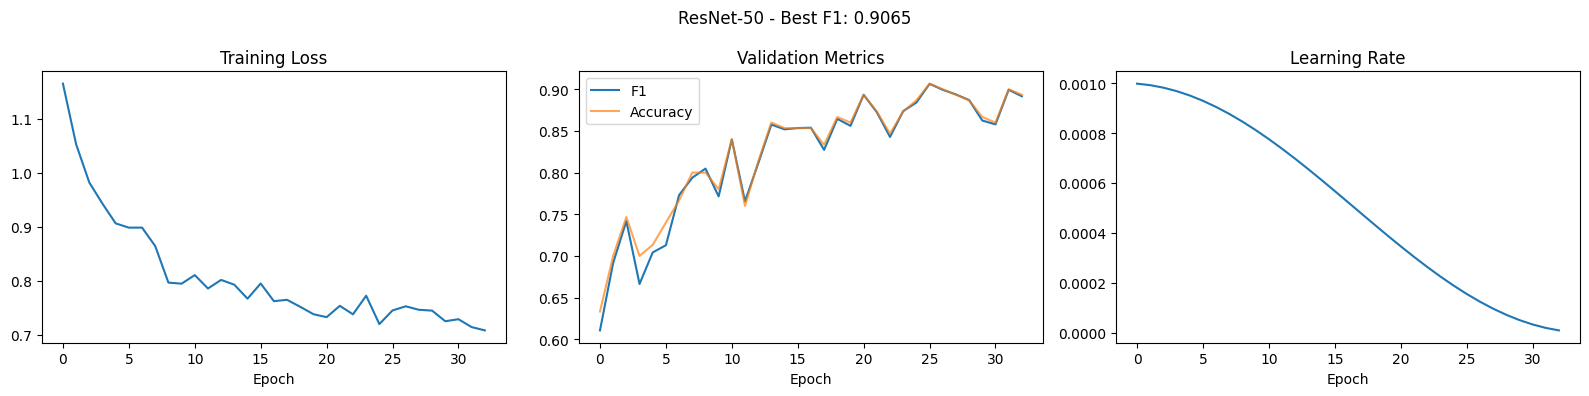

In [20]:
# training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_f1'], label='F1')
axes[1].plot(history['val_acc'], label='Accuracy', alpha=0.7)
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')

plt.suptitle(f'ResNet-50 - Best F1: {best_f1:.4f}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

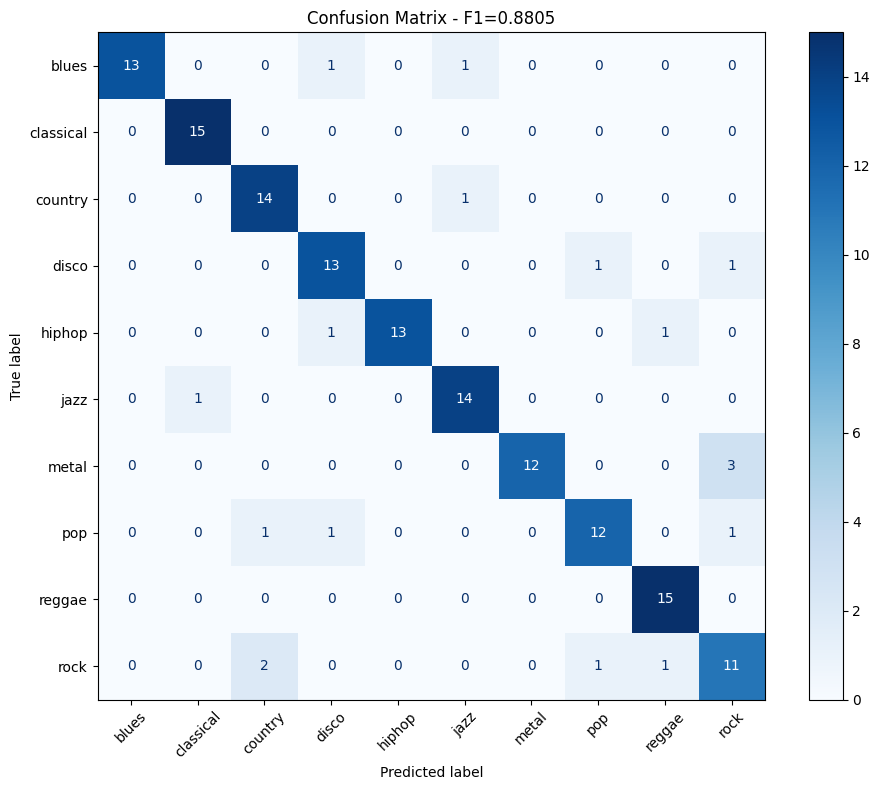

              precision    recall  f1-score   support

       blues       1.00      0.87      0.93        15
   classical       0.94      1.00      0.97        15
     country       0.82      0.93      0.88        15
       disco       0.81      0.87      0.84        15
      hiphop       1.00      0.87      0.93        15
        jazz       0.88      0.93      0.90        15
       metal       1.00      0.80      0.89        15
         pop       0.86      0.80      0.83        15
      reggae       0.88      1.00      0.94        15
        rock       0.69      0.73      0.71        15

    accuracy                           0.88       150
   macro avg       0.89      0.88      0.88       150
weighted avg       0.89      0.88      0.88       150



In [22]:
# confusion matrix on best model
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_cnn.pth'), weights_only=True))
val_f1, val_acc, preds, labels = evaluate(model, val_loader)

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=GENRES).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix - F1={val_f1:.4f}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(classification_report(labels, preds, target_names=GENRES))

### Inference + TTA + Submission

In [23]:
model = GenreResNet(num_classes=10).to(DEVICE)
model.load_state_dict(torch.load(os.path.join("/kaggle/working/outputs/best_cnn.pth"), map_location=DEVICE))
model.eval()

test_ds = TestDataset(TEST_DIR, TEST_CSV)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test samples: {len(test_ds)}")
print(sum(p is None for p in test_ds.paths))

Test samples: 3020
0


In [24]:
@torch.no_grad()
def predict_tta(model, loader, n_tta=5):
    model.eval()
    all_ids = None
    all_probs = []
    for t in range(n_tta):
        round_probs, ids_this_round = [], []
        for wav, ids in loader:
            wav = wav.to(DEVICE)
            mel = wav_batch_to_mel(wav)
            with autocast():
                logits = model(mel)
            round_probs.append(F.softmax(logits, dim=1).float().cpu().numpy())
            ids_this_round.extend(ids)
        all_probs.append(np.vstack(round_probs))
        if all_ids is None:
            all_ids = ids_this_round  # order is stable since shuffle=False
    avg_probs = np.mean(all_probs, axis=0)
    return avg_probs.argmax(1), all_ids, avg_probs

preds, ids, probs = predict_tta(model, test_loader, n_tta=5)
print(f"Prediction distribution: {Counter(preds)}")

Prediction distribution: Counter({np.int64(6): 328, np.int64(9): 327, np.int64(7): 321, np.int64(3): 308, np.int64(8): 307, np.int64(4): 300, np.int64(1): 295, np.int64(5): 290, np.int64(0): 280, np.int64(2): 264})


In [25]:
test_df = pd.read_csv(TEST_CSV, dtype={'id': str})
pred_dict = {str(id_): IDX2GENRES[p] for id_, p in zip(ids, preds)}
test_df['genre'] = test_df['id'].apply(lambda x: pred_dict.get(str(x), 'rock'))
test_df[['id', 'genre']].to_csv(os.path.join(OUTPUT_DIR, 'submission.csv'), index=False)
print("Submission saved!")
print(test_df['genre'].value_counts().sort_index())

np.save(os.path.join(OUTPUT_DIR, 'test_probs_efficientnet.npy'), probs)

Submission saved!
genre
blues        280
classical    295
country      264
disco        308
hiphop       300
jazz         290
metal        328
pop          321
reggae       307
rock         327
Name: count, dtype: int64
